In [6]:
from modules.config import Config as config
from modules.game import GameController
import modules.model as m
import numpy as np
import matplotlib.pyplot as plt
import threading
import traceback
import sys
from IPython.display import display, clear_output

In [ ]:
class TreeConfig:
    num_simulations=800
    num_threads=10
    alpha=1
    epsilon=0.25
    c_base=5
    c_init=1.25
    model='demo'

In [8]:
class Node:

    c_base=TreeConfig.c_base
    c_init=TreeConfig.c_init

    def __init__(self,move=None,parent=None):
        self.move=move
        self.parent=parent
        self.children={}
        self.legal_moves=None
        self.child_priors=None
        self.child_visits=None
        self.child_total_actions=None
        self.lock=threading.RLock()
    
    @property
    def visits(self):
        return self.parent.child_visits[self.move]
    
    @visits.setter
    def visits(self,num_visits):
        self.parent.child_visits[self.move]=num_visits
    
    @property
    def total_action(self):
        return self.parent.child_total_actions[self.move]
    
    @total_action.setter
    def total_action(self,action_value):
        self.parent.child_total_actions[self.move]=action_value

    @property
    def child_mean_actions(self):
        temp=np.where(self.child_visits==0,1,self.child_visits)
        return self.child_total_actions/temp

    def create_children(self,priors,legal_moves,value):
        self.legal_moves=legal_moves
        priors=np.exp(priors-np.max(priors))
        priors[~legal_moves]=np.nan
        if (prior_sum:=np.nansum(priors))!=0:
            priors/=prior_sum
        max_children=np.size(legal_moves)
        self.child_priors=priors
        self.child_visits=np.zeros(max_children)
        self.child_total_actions=np.full(max_children,-1*value)
        for move,is_legal in enumerate(legal_moves):
            if is_legal:
                self.children[move]=Node(move,self)
            
    def update(self,value):
        try:
            self.total_action+=value
        except TypeError:
            self.visits-=1
        
    def get_appraisal(self):
        c=np.log((np.sum(self.child_visits)+self.c_base+1)/self.c_base)+self.c_init
        return self.child_mean_actions+c*self.child_priors*(np.sqrt(np.sum(self.child_visits))/(1+self.child_visits))
    
    def choose_child(self):
        return np.nanargmax(self.get_appraisal())
    
    def choose_move(self,temperature):
        if temperature==1:
            pi=np.exp(self.child_visits-np.max(self.child_visits))
            pi[~self.legal_moves]=0
            pi/=np.sum(pi)
            move=np.random.choice(np.arange(len(pi)),p=pi)
        else:
            visits=np.copy(self.child_visits)
            visits[~self.legal_moves]=np.nan
            moves=np.arange(len(visits))[visits==np.nanmax(visits)]
            if len(moves)>1:
                scores=self.get_appraisal()
                move=moves[np.argmax(scores[moves])]
            else:
                move=moves[0]
        return move
    
class MonteCarloTree:

    width=config.width
    height=config.height
    num_simulations=TreeConfig.num_simulations
    num_threads=TreeConfig.num_threads
    alpha=TreeConfig.alpha
    epsilon=TreeConfig.epsilon
    random=np.random.default_rng()

    def __init__(self,model,noise=True):
        self.root=Node()
        self.model=model
        self.queue_states=np.empty((self.num_threads,self.height,self.width,2))
        self.results=None
        self.to_flip=None
        self.queue_events=[threading.Event() for _ in range(self.num_threads)]
        self.results_event=threading.Event()
        self.exception_occurred=threading.Event()
        self.exception_dict={}
        self.noise=noise

    def choose_move(self,game,temperature): 
        if self.noise and self.root.children:
            self.add_noise()
        evaluator=threading.Thread(target=self.evaluate)
        evaluator.start()
        for _ in range(self.num_simulations//self.num_threads):
            threads=[]
            for i in range(self.num_threads):
                sim_game=game.clone()
                threads.append(threading.Thread(target=self.search,args=[sim_game,i]))
                threads[-1].start()
            if self.exception_occurred.is_set():
                for thread,exception in self.exception_dict.items():
                    print('Exception occured in thread',thread)
                    traceback.print_exception(*exception)
                raise RuntimeError
            for i,thread in enumerate(threads):
                thread.join(120)
                if thread.is_alive():
                    raise RuntimeError('Search thread {} never joined'.format(i))
            self.results_event.clear()
        evaluator.join(120)
        if evaluator.is_alive():
            print('Evaluator never joined')
            raise RuntimeError('Evaluator never joined')
        move=self.root.choose_move(temperature)
        # for node in self.root.children:
        #     print(self.root.children[node].visits)
        pi=self.root.child_visits/np.sum(self.root.child_visits)
        # print('visits:',self.root.child_visits)
        # print('action:',self.root.child_total_actions)
        # print('priors:',self.root.child_priors)
        self.root=self.root.children[move]
        del self.root.parent
        return (move,pi,self.root.child_priors)
        
    def evaluate(self):
        try:
            for _ in range(self.num_simulations//self.num_threads):
                for i in range(self.num_threads):
                    if not self.queue_events[i].wait(60):
                        print('Queue never filled for thread',i)
                        raise RuntimeError
                    self.queue_events[i].clear()
                self.to_flip=self.random.integers(1,size=self.num_threads,endpoint=True).astype(bool)
                self.queue_states[self.to_flip,:,:,:]=np.flip(self.queue_states[self.to_flip,:,:,:],2)
                self.results=self.model(self.queue_states,training=False)
                self.results_event.set()
        except:
            self.exception_occurred.set()
            self.exception_dict[-1]=sys.exc_info()
        
    def search(self,game,thread_id):
        try:
            current_node=self.root
            while current_node.children:
                with current_node.lock:
                    move=current_node.choose_child()
                    game.make_move(move)
                    current_node=current_node.children[move]
                    current_node.update(-1)
                    current_node.visits+=1
            if game.win_state is None and current_node.lock.acquire(blocking=False):
                self.queue_states[thread_id,:,:,:]=game.get_state()
            self.queue_events[thread_id].set()
            if not self.results_event.wait(60):
                print('Never got results')
                raise RuntimeError
            try:
                current_node.lock.release()
            except RuntimeError:
                value=game.win_state
            else:
                if self.to_flip[thread_id]:
                    priors=np.flip(self.results[0][thread_id].numpy())
                else:
                    priors=self.results[0][thread_id].numpy()
                value=self.results[1][thread_id].numpy()
                current_node.create_children(priors,game.get_legal_moves(),value)
            while current_node is not self.root:
                temp=None if value is None else (1+value)
                with current_node.lock:
                    current_node.update(temp)
                current_node=current_node.parent
                if value is not None:
                    value*=-1
        except:
            self.exception_occurred.set()
            self.exception_dict[thread_id]=sys.exc_info()
    
    def add_noise(self):
        priors=self.root.child_priors
        self.root.child_priors=(np.full(np.size(priors),(1-self.epsilon))*priors+self.epsilon
                                *np.random.dirichlet(np.full(np.size(priors),self.alpha)))
    
    def opponent_move(self,move):
        if self.root.children:
            self.root=self.root.children[move]
            del self.root.parent

    def resign(self):
        pass

In [9]:
def plot_board(board):
    game_board=board[:,:,0]+board[:,:,1]*10
    fig,ax=plt.subplots()
    ax.grid(visible=True)
    ax.set_xlim([0,7])
    ax.set_ylim([0,6])
    for y in range(np.shape(game_board)[0]):
        for x in range(np.shape(game_board)[1]):
            if game_board[y,x]==1:
                circle=plt.Circle((x+0.5,y+0.5),0.5,color='r')
                ax.add_patch(circle)
            elif game_board[y,x]==10:
                circle=plt.Circle((x+0.5,y+0.5),0.5,color='y')
                ax.add_patch(circle)
    plt.show()

class HumanPlayer():
    def __init__(self):
        return
    
    def choose_move(self,game,temperature):
        print('Please make a move:')
        move=int(input())
        return move,None,None
    
    def opponent_move(self,move):
        return

def human_play(play_first=True,show_probabilites=True):
    try:
        game=GameController()
        model=m.get_model(TreeConfig.model)
        tree=MonteCarloTree(model,noise=False)
        human=HumanPlayer()
        players=[tree,human]
        current_player=int(play_first)
        if show_probabilites:
            fig,(ax,ax1,ax2)=plt.subplots(1,3,figsize=(24, 6))
            ax1.set_title('Prior')
            ax2.set_title('Policy')
        else:
            fig,ax=plt.subplots()
        ax.grid(visible=True)
        ax.set_xlim([0,7])
        ax.set_ylim([0,6])
        clear_output(wait=True)
        display(fig)
        y=np.zeros(7)
        while game.win_state is None:
            try:
                move,pi,priors=players[current_player].choose_move(game,0)
                game.make_move(move)
                current_player^=1
            except ValueError:
                print('Please input a valid move')
                continue
            c='y' if current_player else 'r'
            ax.add_patch(plt.Circle((move+0.5,y[move]+0.5),0.5,color=c))
            y[move]+=1
            if show_probabilites and current_player:
                ax1.cla()
                ax1.bar(np.arange(7),priors)
                ax1.set_title('Prior')
                ax2.cla()
                ax2.bar(np.arange(7),pi)
                ax2.set_title('Policy')
            clear_output(wait=True)
            display(fig)
            players[current_player].opponent_move(move)
        if game.win_state==0:
            print('Draw!')
        elif not current_player:
            print('You won!')
        else:
            print('Skill issue?')
        plt.close()
    except KeyboardInterrupt:
        plt.close()

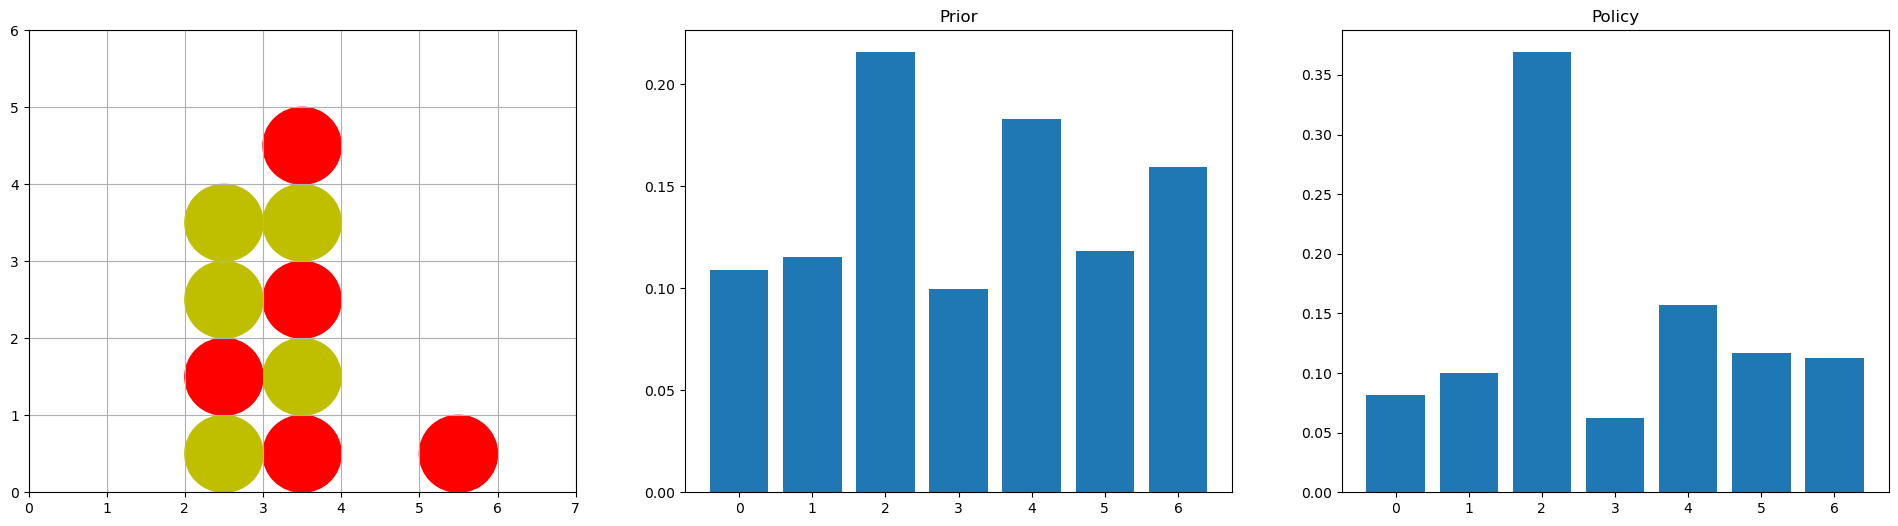

Please make a move:


In [ ]:
human_play(play_first=True,show_probabilites=True)